In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Step 1: Data Preprocessing and Cleaning


In [3]:
def preprocess_data(filepath):
    # Load dataset
    data = pd.read_csv(filepath)

    # Clean column names
    data.columns = data.columns.str.strip().str.replace(' ', '_')

    # Handle percentage columns
    percentage_columns = ['mandala_completion', 'music_completion', 'OverallActivityCompletionRate']
    for col in percentage_columns:
        if col in data.columns:
            data[col] = (
                data[col]
                .astype(str)  # Ensure values are treated as strings for replacement
                .str.replace('%', '', regex=False)
                .replace('nan', None)  # Replace string 'nan' with proper NaN
                .astype(float) / 100
            )

    # Drop irrelevant or unnamed columns
    data = data.drop(columns=["user_ID", "Unnamed:_10", "Unnamed:_11", "Unnamed:_12"], errors='ignore')

    # Mapping for categorical variables
    mapping = {
        "Mandala_Design_Pattern": {"1_(Complex)": 1, "2_(Medium)": 2, "3_(Simple)": 3},
        "Gender": {"Male": 0, "Female": 1, "Other": 2}
    }
    data.replace(mapping, inplace=True)

    return data

# Step 2: Stress Recovery Days Prediction Model


In [4]:
class StressRecoveryModel:
    def __init__(self):
        self.model = RandomForestClassifier(random_state=42)

    def train(self, X_train, y_train):
        self.model.fit(X_train, y_train)

    def evaluate(self, X_test, y_test):
        y_pred = self.model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        return accuracy, report, cm

    def tune_hyperparameters(self, X_train, y_train):
        param_grid = {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10]
        }
        grid_search = GridSearchCV(self.model, param_grid, cv=3, scoring='accuracy')
        grid_search.fit(X_train, y_train)
        self.model = grid_search.best_estimator_
        return grid_search.best_params_

    def save_model(self, filepath):
        joblib.dump(self.model, filepath)

    def load_model(self, filepath):
        self.model = joblib.load(filepath)

    def predict(self, input_data):
        return self.model.predict(input_data)


In [5]:
# Load and preprocess the data
file_path = '../dataset4.csv'
data = preprocess_data(file_path)


data.head()

,Age,Gender,Initial_Stress_Level,Day,Dailystresslevel,DailyEnergyLevel,DailyHappinessLevel,DailyCalmnessLevel,mandala_completion,music_completion,OverallActivityCompletionRate,DurationofParticipation,Base_Recovery_Days,Activity_Multiplier,RecoveryDays
0,28,0,3,1,3,3.0,3,3,0.83,0.50,0.665,30,10,0.2,8
1,28,0,3,2,3,3.0,2,3,0.93,0.65,0.790,25,10,0.2,8
2,28,0,3,3,4,4.0,3,4,1.00,0.72,0.860,40,5,0.4,3
3,28,0,3,4,4,4.0,4,4,0.95,0.84,0.895,35,5,0.4,3
4,28,0,3,5,5,5.0,5,5,1.00,0.89,0.945,50,5,0.8,1


In [6]:
# Split the data
X = data[['Dailystresslevel', 'DailyEnergyLevel', 'DailyHappinessLevel', 'DailyCalmnessLevel', 'OverallActivityCompletionRate', 'DurationofParticipation']]  # Features
y = data["RecoveryDays"]  # Target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Step 3: Training Machine Learning Model


In [7]:
recovery_model = StressRecoveryModel()
recovery_model.train(X_train, y_train)

# Step 4: Evaluating Model Performance


In [8]:
accuracy, report, cm = recovery_model.evaluate(X_test, y_test)
print(f"Initial Accuracy: {accuracy}\n")
print("Classification Report:\n", report)

Initial Accuracy: 0.9964285714285714

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      0.98      0.99        53
           2       1.00      0.67      0.80         3
           3       1.00      1.00      1.00        96
           4       0.99      1.00      0.99        83
           5       1.00      1.00      1.00        39
           6       0.93      1.00      0.97        14
           8       1.00      1.00      1.00        82
          10       1.00      1.00      1.00       105
          12       1.00      1.00      1.00        72

    accuracy                           1.00       560
   macro avg       0.99      0.96      0.98       560
weighted avg       1.00      1.00      1.00       560



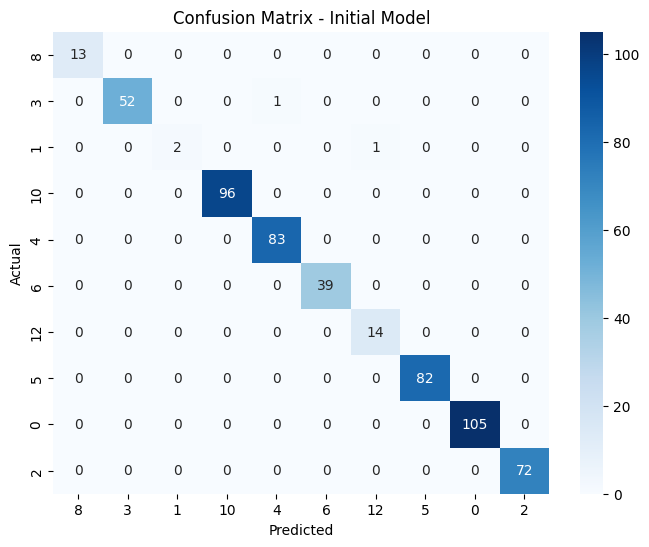

In [9]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=y.unique(), yticklabels=y.unique())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Initial Model')
plt.show()

# Step 5: Deploying the Model and Making Predictions


In [10]:
model_path = 'stress_recovery_model.joblib'
recovery_model.save_model(model_path)
print(f"Model saved to {model_path}")

Model saved to stress_recovery_model.joblib
